# Установка зависимостей

In [ ]:
!pip install pandas numpy matplotlib scikit-learn tensorflow

# Импорт

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
import random
import tensorflow as tf
from sklearn.model_selection import train_test_split

In [2]:
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)
tf.config.experimental.enable_op_determinism()

# Чтение данных

In [4]:
dataframe = pd.read_csv("Iris.csv", index_col=0)
print(dataframe.head())

    SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
Id                                                                       
1             5.1           3.5            1.4           0.2  Iris-setosa
2             4.9           3.0            1.4           0.2  Iris-setosa
3             4.7           3.2            1.3           0.2  Iris-setosa
4             4.6           3.1            1.5           0.2  Iris-setosa
5             5.0           3.6            1.4           0.2  Iris-setosa


# Предобработка данных

In [5]:
dataset = dataframe.values
X = dataset[:, 0:4].astype(float)
y = dataset[:, 4]

encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)
y_categorical = to_categorical(y_encoded)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_categorical,
    test_size=0.2,
    random_state=RANDOM_SEED,
    stratify=np.argmax(y_categorical, axis=1)
)

# Генерация модели

In [7]:
def create_model(architecture, learning_rate=0.001):
    """
    Создание модели с заданной архитектурой

    Параметры:
    architecture: список, где каждый элемент - количество нейронов в слое
    learning_rate: скорость обучения
    """
    model = Sequential()

    # Входной слой
    model.add(Dense(architecture[0], activation='relu', input_shape=(4,)))

    # Скрытые слои
    for neurons in architecture[1:]:
        model.add(Dense(neurons, activation='relu'))

    # Выходной слой
    model.add(Dense(3, activation='softmax'))

    # Компиляция
    optimizer = Adam(learning_rate=learning_rate)
    model.compile(
        optimizer=optimizer,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

# Сравнение Архитектур

In [9]:
architectures = [
    [4],
    [8],
    [16],
    [8, 4],
    [16, 8],
    [32, 16],
    [16, 8, 4],
    [32, 16, 8],
]
architecture_results = []

for arch in architectures:
    print(f"\nОбучение архитектуры: {arch}")

    model = create_model(arch)

    history = model.fit(
        X_train, y_train,
        epochs=100,
        batch_size=10,
        validation_split=0.2,
        verbose=0
    )

    # Оценка на тестовой выборке
    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)

    architecture_results.append({
        'architecture': arch,
        'final_train_acc': history.history['accuracy'][-1],
        'final_val_acc': history.history['val_accuracy'][-1],
        'test_acc': test_acc,
        'history': history
    })

    print(f"\tТочность на валидации: {history.history['val_accuracy'][-1]:.4f}")
    print(f"\tТочность на тесте: {test_acc:.4f}")


Обучение архитектуры: [4]
	Точность на валидации: 0.8333
	Точность на тесте: 0.7667

Обучение архитектуры: [8]
	Точность на валидации: 0.9583
	Точность на тесте: 0.8333

Обучение архитектуры: [16]
	Точность на валидации: 1.0000
	Точность на тесте: 0.9000

Обучение архитектуры: [8, 4]
	Точность на валидации: 1.0000
	Точность на тесте: 0.9333

Обучение архитектуры: [16, 8]
	Точность на валидации: 1.0000
	Точность на тесте: 0.9333

Обучение архитектуры: [32, 16]
	Точность на валидации: 1.0000
	Точность на тесте: 0.9667

Обучение архитектуры: [16, 8, 4]
	Точность на валидации: 1.0000
	Точность на тесте: 0.9667

Обучение архитектуры: [32, 16, 8]
	Точность на валидации: 1.0000
	Точность на тесте: 0.9667


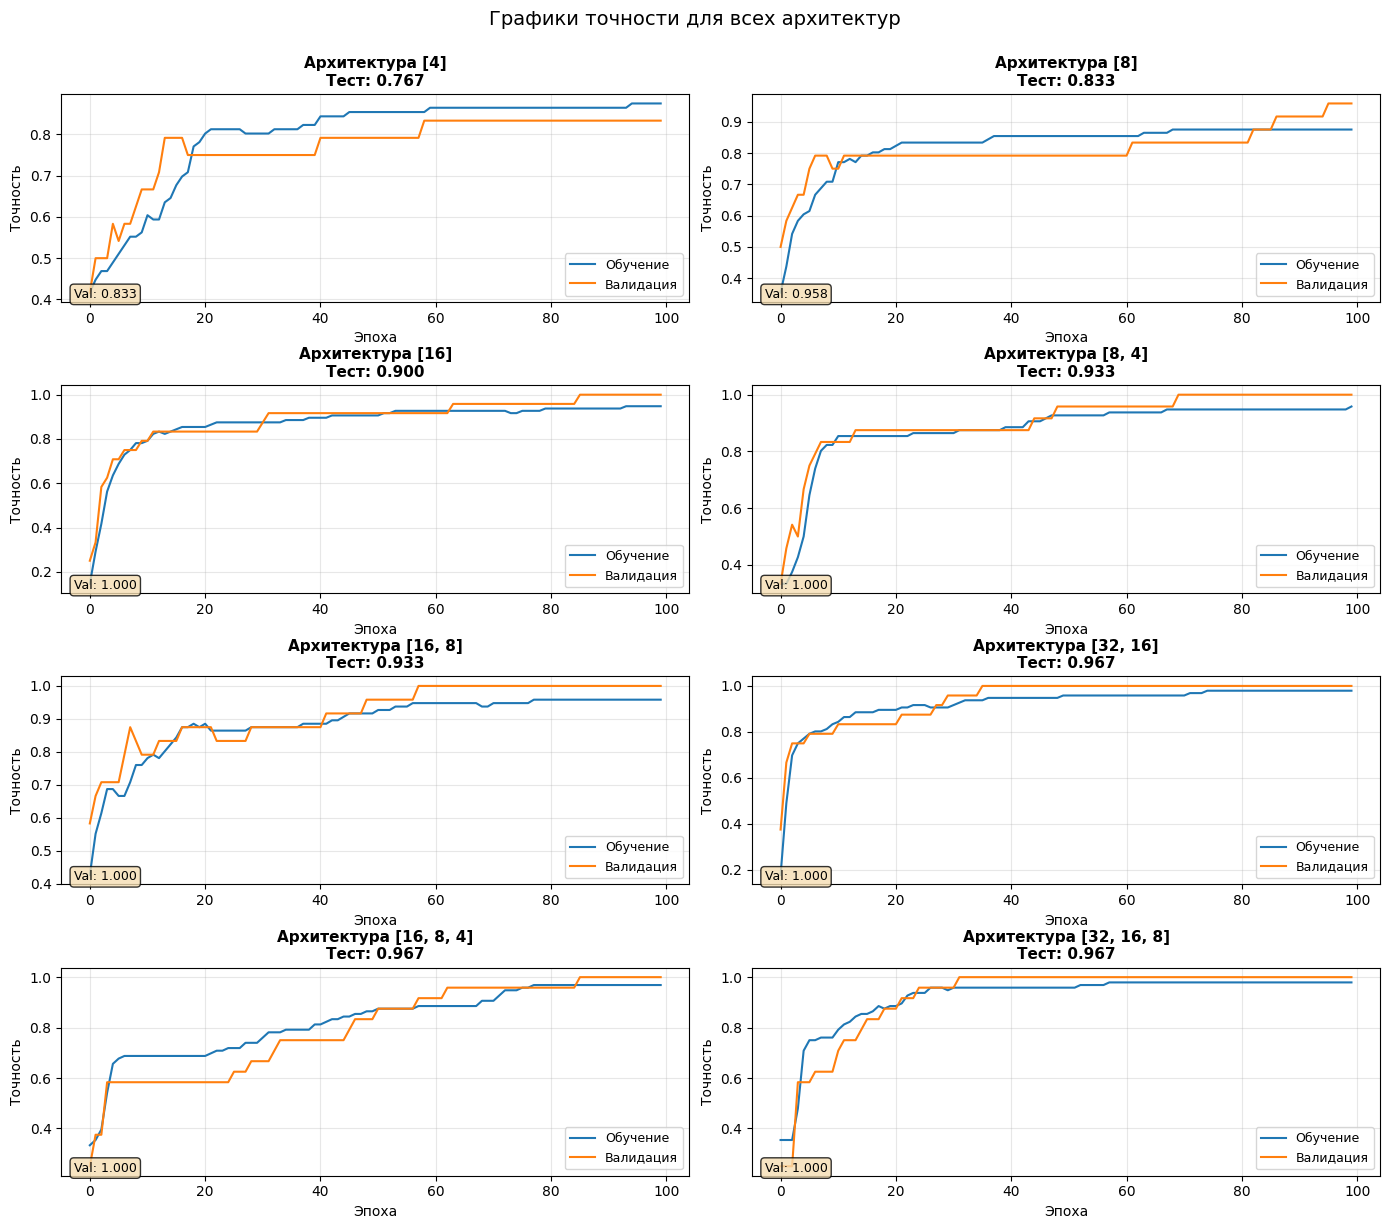

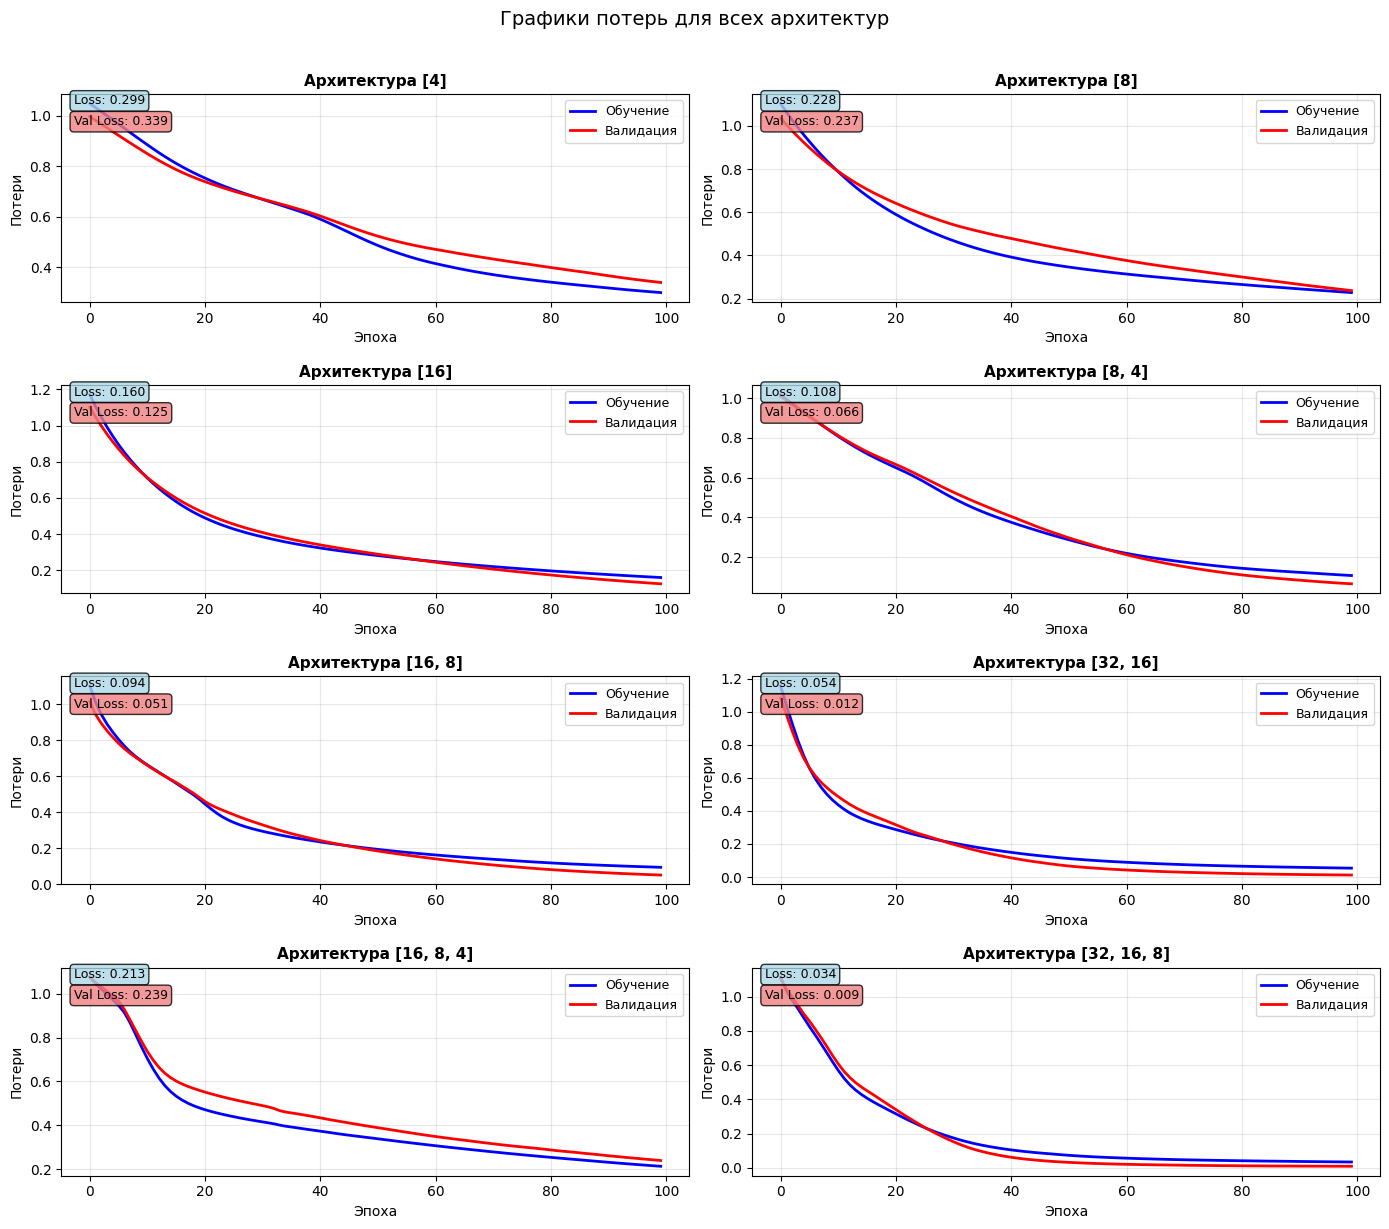

In [10]:
def plot_accuracy_grid(architecture_results, architectures):
    """
    Построение сетки 4x2 графиков точности для всех архитектур
    """
    fig, axes = plt.subplots(4, 2, figsize=(14, 12))
    fig.suptitle('Графики точности для всех архитектур', fontsize=14, y=1.02)

    for idx, (arch, ax) in enumerate(zip(architectures, axes.flat)):
        result = next(r for r in architecture_results if r['architecture'] == arch)
        history = result['history']

        ax.plot(history.history['accuracy'], label='Обучение')
        ax.plot(history.history['val_accuracy'], label='Валидация')

        ax.set_xlabel('Эпоха', fontsize=10)
        ax.set_ylabel('Точность', fontsize=10)
        ax.set_title(f'Архитектура {arch}\nТест: {result["test_acc"]:.3f}',
                    fontsize=11, fontweight='bold')
        ax.legend(loc='lower right', fontsize=9)
        ax.grid(True, alpha=0.3)

        ax.text(0.02, 0.02, f'Val: {result["final_val_acc"]:.3f}',
                transform=ax.transAxes, fontsize=9,
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

    plt.tight_layout()
    plt.subplots_adjust(top=0.95, hspace=0.4, wspace=0.1)
    plt.savefig('accuracy_grid.png', dpi=300, bbox_inches='tight')
    plt.show()


def plot_loss_grid(architecture_results, architectures):
    """
    Построение сетки 4x2 графиков потерь для всех архитектур
    """
    fig, axes = plt.subplots(4, 2, figsize=(14, 12))
    fig.suptitle('Графики потерь для всех архитектур', fontsize=14, y=1.02)

    for idx, (arch, ax) in enumerate(zip(architectures, axes.flat)):
        result = next(r for r in architecture_results if r['architecture'] == arch)
        history = result['history']

        ax.plot(history.history['loss'], 'b-', linewidth=2, label='Обучение')
        ax.plot(history.history['val_loss'], 'r-', linewidth=2, label='Валидация')

        ax.set_xlabel('Эпоха', fontsize=10)
        ax.set_ylabel('Потери', fontsize=10)
        ax.set_title(f'Архитектура {arch}', fontsize=11, fontweight='bold')
        ax.legend(loc='upper right', fontsize=9)
        ax.grid(True, alpha=0.3)

        ax.text(0.02, 0.95, f'Loss: {history.history["loss"][-1]:.3f}',
                transform=ax.transAxes, fontsize=9,
                bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))
        ax.text(0.02, 0.85, f'Val Loss: {history.history["val_loss"][-1]:.3f}',
                transform=ax.transAxes, fontsize=9,
                bbox=dict(boxstyle='round', facecolor='lightcoral', alpha=0.8))

    plt.tight_layout()
    plt.subplots_adjust(top=0.95, hspace=0.4, wspace=0.1)
    plt.savefig('loss_grid.png', dpi=300, bbox_inches='tight')
    plt.show()


plot_accuracy_grid(architecture_results, architectures)
plot_loss_grid(architecture_results, architectures)

# Сравнение параметров обучения

In [26]:
def plot_parameter_comparison(results, param_name, param_values, baseline_acc=None, metric='accuracy'):
    """
    Строит два подграфика: слева – точность, справа – потери.
    Для каждого значения параметра рисуются кривые обучения и валидации.
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'Влияние параметра {param_name}', fontsize=14)

    colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(results)))

    for res, color in zip(results, colors):
        val = res['value']
        hist = res['history']
        # Точность
        ax1.plot(hist.history['accuracy'], color=color, linestyle='-',
                 label=f'{param_name}={val} (train)')
        ax1.plot(hist.history['val_accuracy'], color=color, linestyle='--',
                 label=f'{param_name}={val} (val)')
        # Потери
        ax2.plot(hist.history['loss'], color=color, linestyle='-',
                 label=f'{param_name}={val} (train)')
        ax2.plot(hist.history['val_loss'], color=color, linestyle='--',
                 label=f'{param_name}={val} (val)')

    ax1.set_xlabel('Эпоха')
    ax1.set_ylabel('Точность')
    ax1.set_title('Точность на обучении и валидации')
    ax1.legend(loc='lower right', fontsize=8)
    ax1.grid(True, alpha=0.3)
    if baseline_acc is not None:
        ax1.axhline(y=baseline_acc, color='red', linestyle=':',
                    label=f'Базовая модель ({baseline_acc:.3f})')

    ax2.set_xlabel('Эпоха')
    ax2.set_ylabel('Потери')
    ax2.set_title('Потери на обучении и валидации')
    ax2.legend(loc='upper right', fontsize=8)
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

def plot_final_accuracy(results, param_name, baseline_acc):
    values = [r['value'] for r in results]
    test_accs = [r['test_acc'] for r in results]

    plt.figure(figsize=(8, 5))
    bars = plt.bar(range(len(values)), test_accs, tick_label=values, color='skyblue')
    plt.axhline(y=baseline_acc, color='red', linestyle='--', label=f'Базовая ({baseline_acc:.3f})')
    plt.xlabel(param_name)
    plt.ylabel('Точность на тесте')
    plt.title(f'Финальная точность при разных {param_name}')
    plt.legend()
    # Подписи значений над столбцами
    for bar, acc in zip(bars, test_accs):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{acc:.3f}', ha='center', va='bottom', fontsize=9)
    plt.tight_layout()
    plt.show()

## Размер батча

In [14]:
TARGET_ARCH = architectures[0]
BASELINE_ACC = architecture_results[0]['test_acc']
batch_results = []
batch_sizes = [2, 4, 8, 16, 32, 64]
batch_best_acc = 0
batch_best_value = None

for batch_size in batch_sizes:
    print(f"\n* batch_size = {batch_size}")

    model = create_model(TARGET_ARCH)

    history = model.fit(
        X_train, y_train,
        epochs=100,
        batch_size=batch_size,
        validation_split=0.2,
        verbose=0
    )

    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)

    print(f"\tТочность на тесте: {test_acc:.4f}  (было: {BASELINE_ACC:.4f})")
    print(f"\tИзменение: {test_acc - BASELINE_ACC:+.4f}")

    if test_acc > batch_best_acc:
        batch_best_acc = test_acc
        batch_best_value = batch_size

    batch_results.append({
        'value': batch_size,
        'test_acc': test_acc,
        'history': history
    })

print(f"\nЛучший batch_size: {batch_best_value} (точность: {batch_best_acc:.4f})")


* batch_size = 2
	Точность на тесте: 0.9333  (было: 0.7667)
	Изменение: +0.1667

* batch_size = 4
	Точность на тесте: 0.9000  (было: 0.7667)
	Изменение: +0.1333

* batch_size = 8
	Точность на тесте: 0.8333  (было: 0.7667)
	Изменение: +0.0667

* batch_size = 16
	Точность на тесте: 0.6667  (было: 0.7667)
	Изменение: -0.1000

* batch_size = 32
	Точность на тесте: 0.8667  (было: 0.7667)
	Изменение: +0.1000

* batch_size = 64
	Точность на тесте: 0.1333  (было: 0.7667)
	Изменение: -0.6333

	Лучший batch_size: 2 (точность: 0.9333)


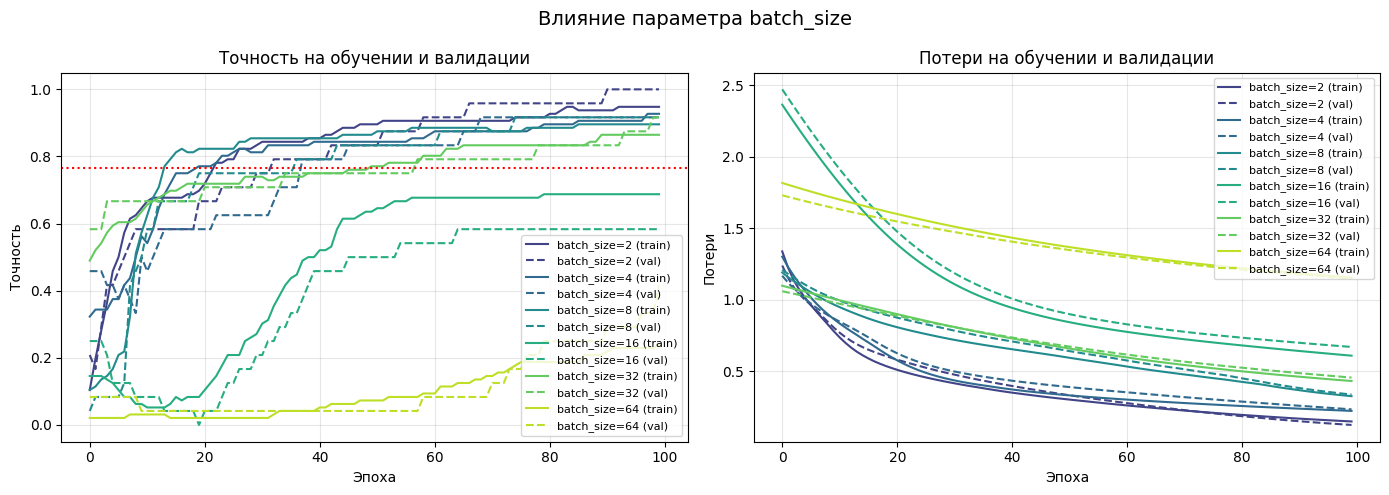

In [21]:
baseline = architecture_results[0]['test_acc']
plot_parameter_comparison(batch_results, 'batch_size', batch_sizes, baseline)

## Количество эпох

In [16]:
TARGET_ARCH = architectures[0]
BASELINE_ACC = architecture_results[0]['test_acc']
epochs_results = []
epochs_list = [50, 100, 150, 200, 300]
epochs_best_acc = 0
epochs_best_value = None

for epochs in epochs_list:
    print(f"\n* epochs = {epochs}")

    model = create_model(TARGET_ARCH)

    history = model.fit(
        X_train, y_train,
        epochs=epochs,
        batch_size=16,
        validation_split=0.2,
        verbose=0
    )

    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)

    # Анализ переобучения
    train_acc = history.history['accuracy'][-1]
    val_acc = history.history['val_accuracy'][-1]
    overfitting = train_acc - val_acc

    print(f"\tТочность на тесте: {test_acc:.4f}  (было: {BASELINE_ACC:.4f})")
    print(f"\tИзменение: {test_acc - BASELINE_ACC:+.4f}")
    print(f"\tРазрыв train-val: {overfitting:.4f}")

    if test_acc > epochs_best_acc:
        epochs_best_acc = test_acc
        epochs_best_value = epochs

    epochs_results.append({
        'value': epochs,
        'test_acc': test_acc,
        'history': history
    })

print(f"\nЛучшее количество эпох: {epochs_best_value} (точность: {epochs_best_acc:.4f})")



* epochs = 50
	Точность на тесте: 0.7667  (было: 0.7667)
	Изменение: +0.0000
	Разрыв train-val: 0.1771

* epochs = 100
	Точность на тесте: 0.7667  (было: 0.7667)
	Изменение: +0.0000
	Разрыв train-val: 0.0000

* epochs = 150
	Точность на тесте: 0.7333  (было: 0.7667)
	Изменение: -0.0333
	Разрыв train-val: 0.0104

* epochs = 200
	Точность на тесте: 0.8333  (было: 0.7667)
	Изменение: +0.0667
	Разрыв train-val: -0.0729

* epochs = 300
	Точность на тесте: 0.8667  (было: 0.7667)
	Изменение: +0.1000
	Разрыв train-val: -0.0521

Лучшее количество эпох: 300 (точность: 0.8667)


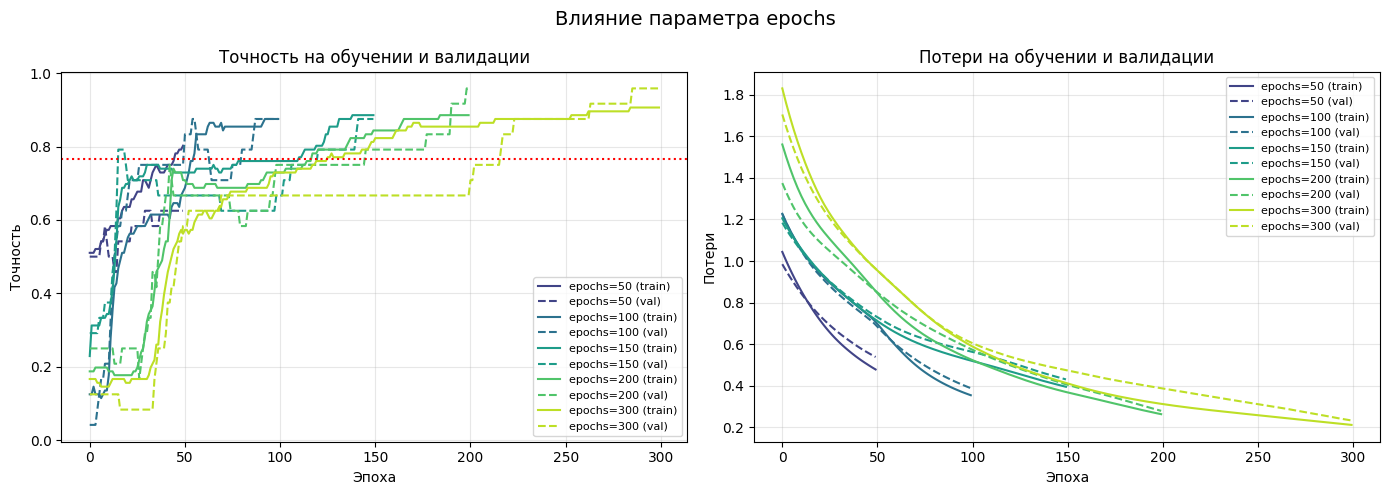

In [22]:
baseline = architecture_results[0]['test_acc']
plot_parameter_comparison(epochs_results, 'epochs', epochs_list, baseline)

## Соотношение разбиения данных для валидации

In [18]:
TARGET_ARCH = architectures[0]
BASELINE_ACC = architecture_results[0]['test_acc']
split_results = []
val_splits = [0.1, 0.15, 0.2, 0.25, 0.3]
split_best_acc = 0
split_best_value = None

for val_split in val_splits:
    print(f"\n* validation_split = {val_split}")

    model = create_model(TARGET_ARCH)

    history = model.fit(
        X_train, y_train,
        epochs=100,
        batch_size=16,
        validation_split=val_split,
        verbose=0
    )

    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)

    print(f"\tТочность на тесте: {test_acc:.4f}  (было: {BASELINE_ACC:.4f})")
    print(f"\tИзменение: {test_acc - BASELINE_ACC:+.4f}")

    if test_acc > split_best_acc:
        split_best_acc = test_acc
        split_best_value = val_split

    split_results.append({
        'value': val_split,
        'test_acc': test_acc,
        'history': history
    })

print(f"\nЛучший validation_split: {split_best_value} (точность: {split_best_acc:.4f})")


* validation_split = 0.1
	Точность на тесте: 0.9667  (было: 0.7667)
	Изменение: +0.2000

* validation_split = 0.15
	Точность на тесте: 0.7667  (было: 0.7667)
	Изменение: +0.0000

* validation_split = 0.2
	Точность на тесте: 0.8000  (было: 0.7667)
	Изменение: +0.0333

* validation_split = 0.25
	Точность на тесте: 0.7667  (было: 0.7667)
	Изменение: +0.0000

* validation_split = 0.3
	Точность на тесте: 0.7667  (было: 0.7667)
	Изменение: +0.0000

Лучший validation_split: 0.1 (точность: 0.9667)


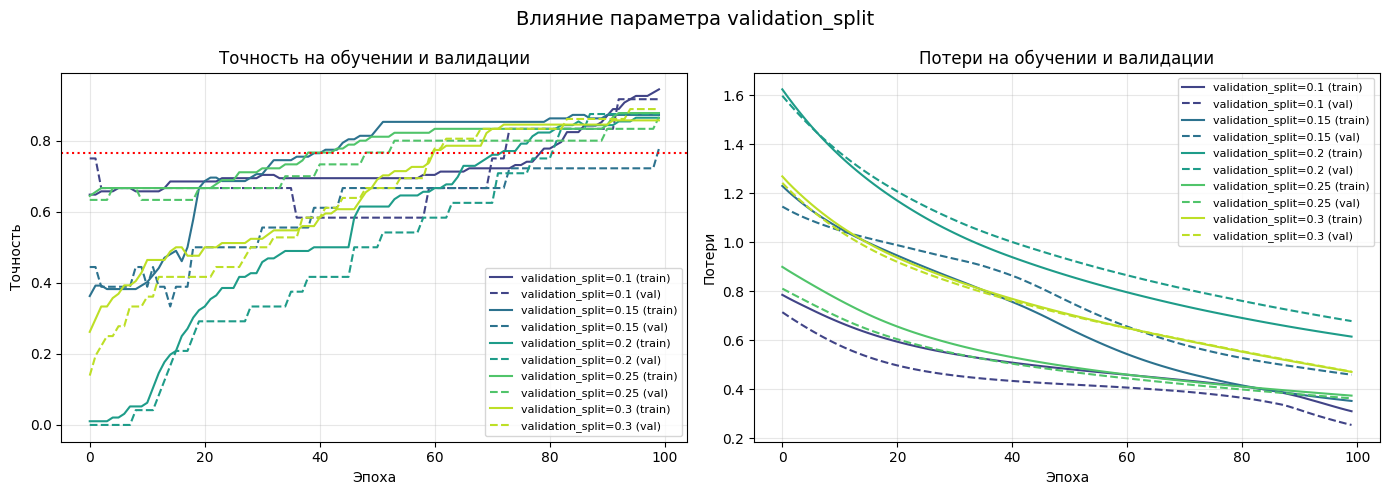

In [23]:
baseline = architecture_results[0]['test_acc']
plot_parameter_comparison(split_results, 'validation_split', val_splits, baseline)

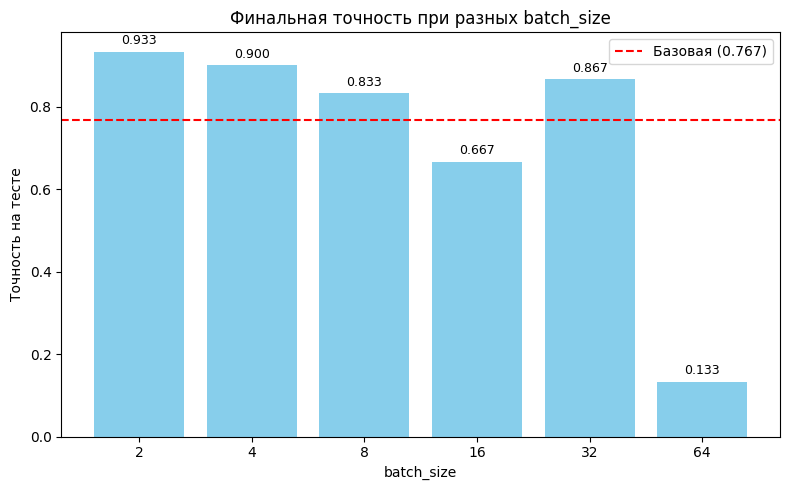

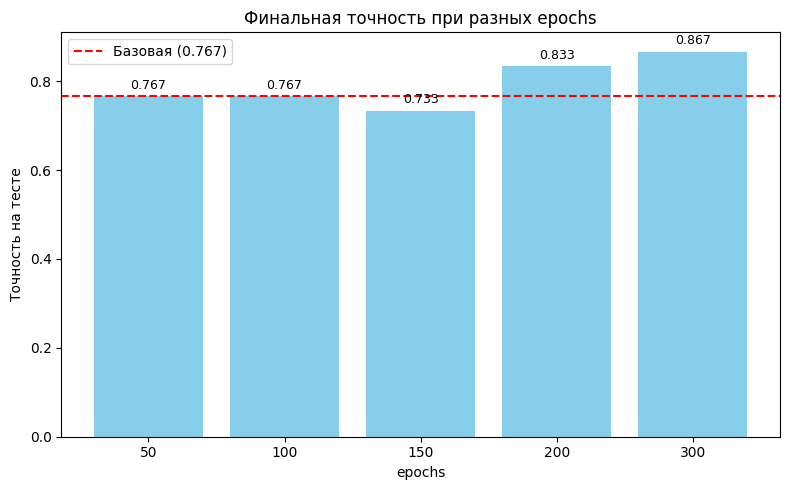

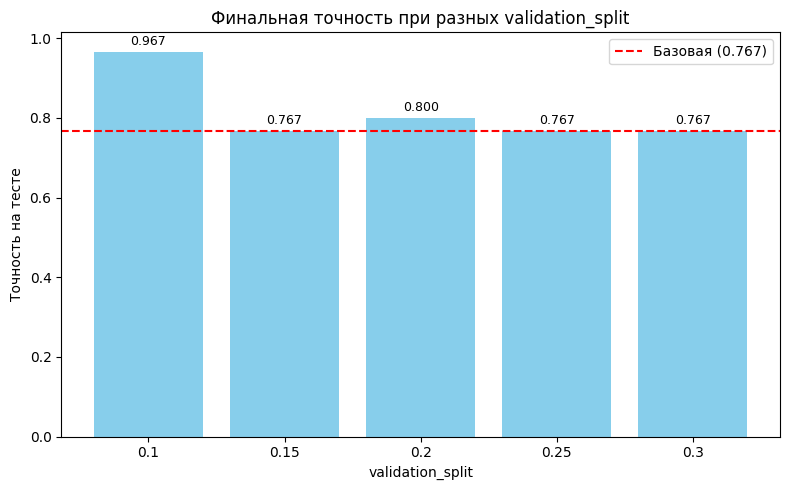

In [27]:
baseline = architecture_results[0]['test_acc']
plot_final_accuracy(batch_results, 'batch_size', baseline)
plot_final_accuracy(epochs_results, 'epochs', baseline)
plot_final_accuracy(split_results, 'validation_split', baseline)